# Lab 3: Unsupervised Learning — KMeans, DBSCAN, PCA, and KMeans Variants

## Objective
In this lab, you will explore **unsupervised learning algorithms** using the **Wine dataset**.  
You’ll apply:
- **KMeans** and determine the optimal number of clusters.  
- **DBSCAN** for density-based clustering and anomaly detection.  
- **PCA** for dimensionality reduction and performance comparison.  
- **A research-based KMeans variant** (e.g., MiniBatchKMeans, Bisecting KMeans, Kernel KMeans).  

You will **quantitatively evaluate** each approach using metrics such as:
- Silhouette Score  
- Calinski–Harabasz Index  
- Davies–Bouldin Index  
- Runtime Efficiency  

---

## 1 - Setup and Data Loading (5pts)

In this section, you will:
1. Load the Wine dataset from `sklearn.datasets`.
2. Inspect the dataset’s structure (features, types, missing values).
3. Standardize the feature values to prepare for clustering.

```python
# TODO: Import necessary libraries
# Suggested imports:
# pandas, numpy, matplotlib, sklearn (datasets, preprocessing)

from sklearn.datasets import load_wine
import pandas as pd

# Load the dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Display the first few rows
df.head()

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load the Wine dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (178, 14)

First few rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_di

In [4]:
# Standardize the features (excluding target)
X = df.drop('target', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=wine.feature_names)

print("Original data (first 5 rows):")
print(X.head())
print("\nStandardized data (first 5 rows):")
print(X_scaled_df.head())

# Use X_scaled for all subsequent clustering
X = X_scaled

Original data (first 5 rows):
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines 

# 2 - Implement KMeans for k = 2 to 10 and compute inertia and silhouette scores

```python
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
```

# Plot Elbow and Silhouette Score


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time

# Initialize lists to store results
K = range(2, 11)
inertias = []
silhouette_scores = []
runtimes = []

# Compute KMeans for k = 2 to 10
for k in K:
    start_time = time.time()
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    
    runtime = time.time() - start_time
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    runtimes.append(runtime)
    
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.3f}, Runtime={runtime:.4f}s")

# Store results in a DataFrame
kmeans_results = pd.DataFrame({
    'k': list(K),
    'inertia': inertias,
    'silhouette_score': silhouette_scores,
    'runtime': runtimes
})

print("\nKMeans Results Summary:")
print(kmeans_results)

k=2: Inertia=1658.76, Silhouette=0.259, Runtime=2.3259s
k=3: Inertia=1277.93, Silhouette=0.285, Runtime=0.0630s
k=4: Inertia=1175.43, Silhouette=0.260, Runtime=0.0576s
k=5: Inertia=1109.51, Silhouette=0.202, Runtime=0.0607s
k=6: Inertia=1046.00, Silhouette=0.237, Runtime=0.0583s
k=7: Inertia=981.60, Silhouette=0.204, Runtime=0.0544s
k=8: Inertia=935.20, Silhouette=0.157, Runtime=0.0560s
k=9: Inertia=889.89, Silhouette=0.150, Runtime=0.0551s
k=10: Inertia=845.90, Silhouette=0.144, Runtime=0.0658s

KMeans Results Summary:
    k      inertia  silhouette_score   runtime
0   2  1658.758852          0.259317  2.325898
1   3  1277.928489          0.284859  0.063024
2   4  1175.428333          0.260170  0.057583
3   5  1109.512739          0.201619  0.060676
4   6  1046.002333          0.237167  0.058334
5   7   981.595233          0.203628  0.054445
6   8   935.201211          0.157014  0.056007
7   9   889.892911          0.149882  0.055136
8  10   845.895237          0.143638  0.065825


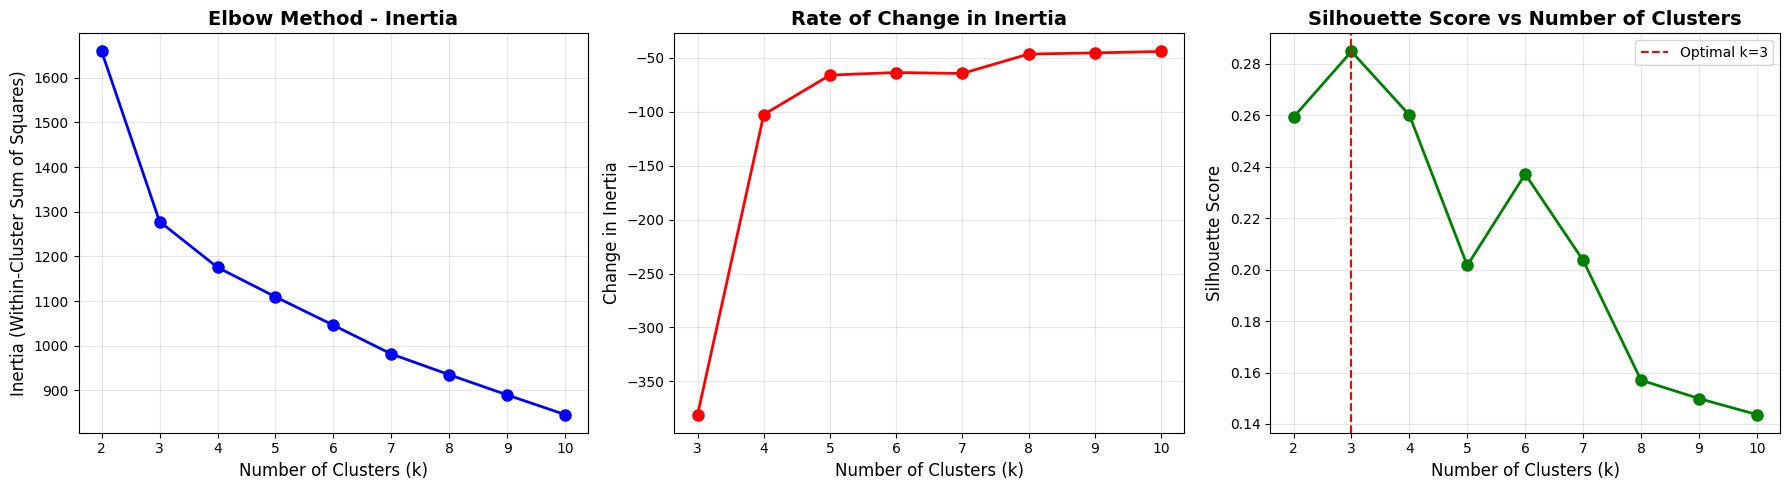


Optimal number of clusters based on Silhouette Score: k=3
Best Silhouette Score: 0.2849


In [6]:
# Plot Elbow Curve and Silhouette Scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow Plot - Inertia
axes[0].plot(K, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method - Inertia', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K)

# Elbow Plot - Rate of Change in Inertia
inertia_diff = np.diff(inertias)
axes[1].plot(list(K)[1:], inertia_diff, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Change in Inertia', fontsize=12)
axes[1].set_title('Rate of Change in Inertia', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(K)[1:])

# Silhouette Score Plot
axes[2].plot(K, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[2].set_ylabel('Silhouette Score', fontsize=12)
axes[2].set_title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(K)

# Highlight optimal k based on silhouette score
optimal_k = kmeans_results.loc[kmeans_results['silhouette_score'].idxmax(), 'k']
optimal_silhouette = kmeans_results['silhouette_score'].max()
axes[2].axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={int(optimal_k)}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nOptimal number of clusters based on Silhouette Score: k={int(optimal_k)}")
print(f"Best Silhouette Score: {optimal_silhouette:.4f}")

# 3 - Implement DBSCAN with different parameter values

```python
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Count clusters and outliers
```


In [7]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

dbscan = DBSCAN(eps=0.6, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Test different parameter combinations
eps_values = [0.5, 0.6, 0.7, 0.8, 1.0, 1.2, 1.5]
min_samples_values = [3, 5, 7, 10]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_outliers = list(labels).count(-1)
        
        result = {
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_outliers': n_outliers,
            'outlier_ratio': n_outliers / len(labels)
        }
        
        # Calculate metrics only if we have valid clusters
        if n_clusters > 1:
            # Filter out outliers for metric calculation
            mask = labels != -1
            if mask.sum() > 0:
                result['silhouette'] = silhouette_score(X[mask], labels[mask])
                result['calinski_harabasz'] = calinski_harabasz_score(X[mask], labels[mask])
                result['davies_bouldin'] = davies_bouldin_score(X[mask], labels[mask])
            else:
                result['silhouette'] = np.nan
                result['calinski_harabasz'] = np.nan
                result['davies_bouldin'] = np.nan
        else:
            result['silhouette'] = np.nan
            result['calinski_harabasz'] = np.nan
            result['davies_bouldin'] = np.nan
        
        dbscan_results.append(result)

dbscan_df = pd.DataFrame(dbscan_results)
print("DBSCAN Results:")
print(dbscan_df.to_string())

# Find best configuration (highest silhouette score)
valid_results = dbscan_df.dropna(subset=['silhouette'])
if not valid_results.empty:
    best_idx = valid_results['silhouette'].idxmax()
    best_config = dbscan_df.loc[best_idx]
    print(f"\nBest DBSCAN Configuration:")
    print(f"eps={best_config['eps']}, min_samples={best_config['min_samples']}")
    print(f"Clusters: {best_config['n_clusters']}, Outliers: {best_config['n_outliers']}")
    print(f"Silhouette Score: {best_config['silhouette']:.4f}")

DBSCAN Results:
    eps  min_samples  n_clusters  n_outliers  outlier_ratio  silhouette  calinski_harabasz  davies_bouldin
0   0.5            3           0         178       1.000000         NaN                NaN             NaN
1   0.5            5           0         178       1.000000         NaN                NaN             NaN
2   0.5            7           0         178       1.000000         NaN                NaN             NaN
3   0.5           10           0         178       1.000000         NaN                NaN             NaN
4   0.6            3           0         178       1.000000         NaN                NaN             NaN
5   0.6            5           0         178       1.000000         NaN                NaN             NaN
6   0.6            7           0         178       1.000000         NaN                NaN             NaN
7   0.6           10           0         178       1.000000         NaN                NaN             NaN
8   0.7            3 

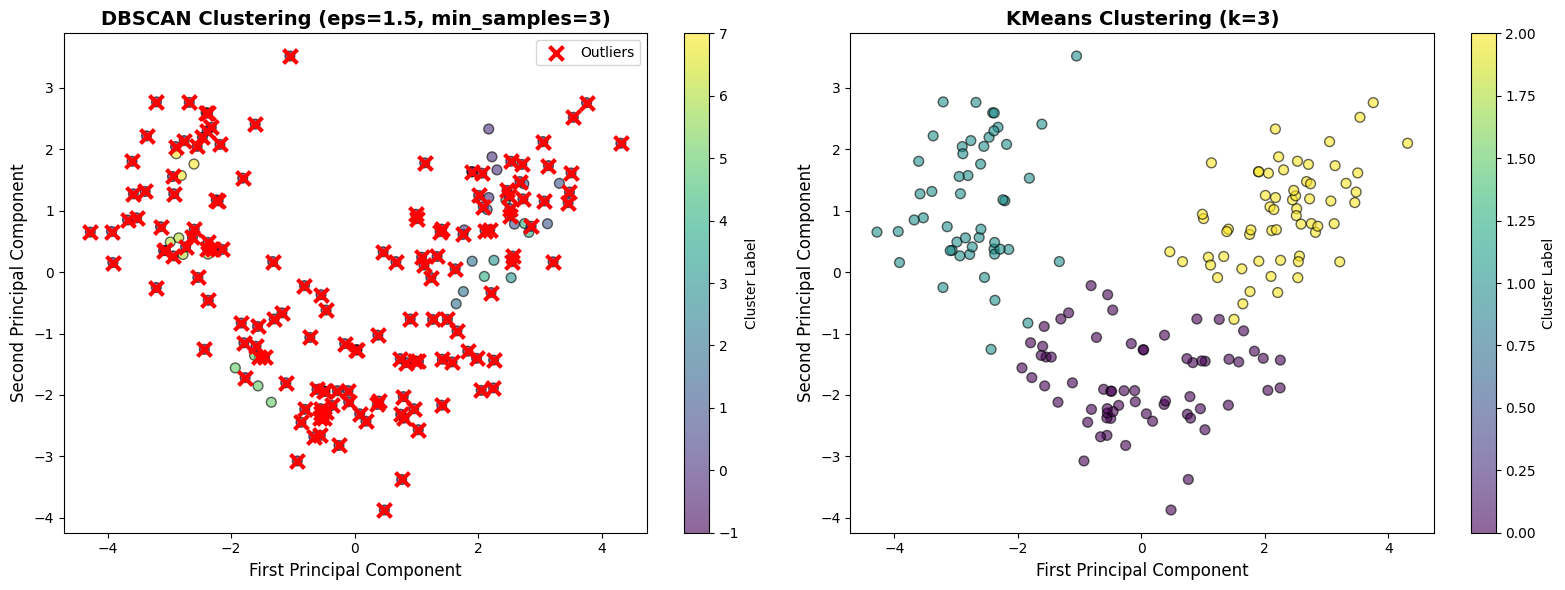


Outlier indices: [  1   2   3   4   5   7   8  10  11  12  13  14  18  19  21  25  27  28
  30  31  32  33  34  36  37  38  39  41  42  43  45  46  48  49  50  51
  52  55  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  93  94
  95  96  97  98  99 100 101 102 103 104 105 106 108 109 110 111 112 113
 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131
 132 133 134 135 136 137 138 141 143 144 145 146 147 149 150 151 152 153
 154 155 157 158 159 160 161 163 164 165 166 167 168 169 170 171 172 173
 175 176 177]
Number of outliers: 147


In [8]:
# Visualize DBSCAN with best parameters
best_eps = best_config['eps']
best_min_samples = int(best_config['min_samples'])

dbscan_best = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan_best.fit_predict(X)

# Apply PCA for 2D visualization
from sklearn.decomposition import PCA
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN visualization
scatter = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=dbscan_labels, 
                          cmap='viridis', s=50, alpha=0.6, edgecolors='k')
axes[0].set_xlabel('First Principal Component', fontsize=12)
axes[0].set_ylabel('Second Principal Component', fontsize=12)
axes[0].set_title(f'DBSCAN Clustering (eps={best_eps}, min_samples={best_min_samples})', 
                  fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Cluster Label')

# Highlight outliers
outliers = X_pca_2d[dbscan_labels == -1]
axes[0].scatter(outliers[:, 0], outliers[:, 1], c='red', s=100, 
                marker='x', linewidths=3, label='Outliers')
axes[0].legend()

# KMeans comparison (using optimal k)
kmeans_optimal = KMeans(n_clusters=int(optimal_k), random_state=42)
kmeans_labels_optimal = kmeans_optimal.fit_predict(X)

scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels_optimal, 
                           cmap='viridis', s=50, alpha=0.6, edgecolors='k')
axes[1].set_xlabel('First Principal Component', fontsize=12)
axes[1].set_ylabel('Second Principal Component', fontsize=12)
axes[1].set_title(f'KMeans Clustering (k={int(optimal_k)})', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Cluster Label')

plt.tight_layout()
plt.show()

print(f"\nOutlier indices: {np.where(dbscan_labels == -1)[0]}")
print(f"Number of outliers: {sum(dbscan_labels == -1)}")

In [9]:
# Compare DBSCAN vs KMeans
comparison_data = {
    'Algorithm': ['DBSCAN', 'KMeans'],
    'n_clusters': [best_config['n_clusters'], int(optimal_k)],
    'n_outliers': [best_config['n_outliers'], 0],
}

# Add silhouette scores
mask_dbscan = dbscan_labels != -1
if mask_dbscan.sum() > 1:
    comparison_data['silhouette_score'] = [
        silhouette_score(X[mask_dbscan], dbscan_labels[mask_dbscan]),
        silhouette_score(X, kmeans_labels_optimal)
    ]
else:
    comparison_data['silhouette_score'] = [np.nan, silhouette_score(X, kmeans_labels_optimal)]

comparison_df = pd.DataFrame(comparison_data)
print("\nDBSCAN vs KMeans Comparison:")
print(comparison_df)


DBSCAN vs KMeans Comparison:
  Algorithm  n_clusters  n_outliers  silhouette_score
0    DBSCAN         8.0       147.0          0.331067
1    KMeans         3.0         0.0          0.284859


# 4 - Apply PCA and visualize explained variance ratio

```python
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X)
```

Explained Variance Ratio by Component:
PC1: 0.3620 (Cumulative: 0.3620)
PC2: 0.1921 (Cumulative: 0.5541)
PC3: 0.1112 (Cumulative: 0.6653)
PC4: 0.0707 (Cumulative: 0.7360)
PC5: 0.0656 (Cumulative: 0.8016)
PC6: 0.0494 (Cumulative: 0.8510)
PC7: 0.0424 (Cumulative: 0.8934)
PC8: 0.0268 (Cumulative: 0.9202)
PC9: 0.0222 (Cumulative: 0.9424)
PC10: 0.0193 (Cumulative: 0.9617)
PC11: 0.0174 (Cumulative: 0.9791)
PC12: 0.0130 (Cumulative: 0.9920)
PC13: 0.0080 (Cumulative: 1.0000)


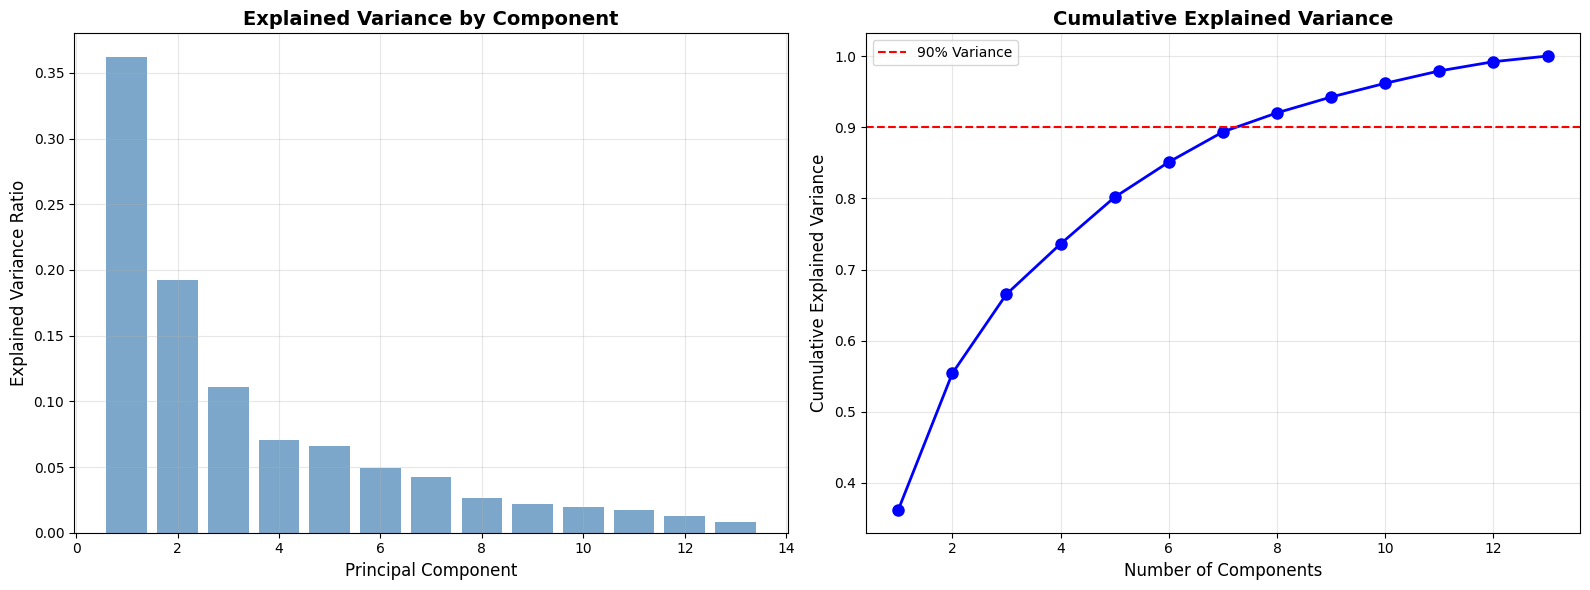


Number of components needed for ≥90% variance: 8
Cumulative variance with 8 components: 0.9202


In [10]:
from sklearn.decomposition import PCA

# Apply PCA with all components
pca = PCA()
X_pca = pca.fit_transform(X)

# Get explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained Variance Ratio by Component:")
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"PC{i+1}: {var:.4f} (Cumulative: {cum_var:.4f})")

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Individual explained variance
axes[0].bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Explained Variance by Component', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
             'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=0.9, color='r', linestyle='--', label='90% Variance')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Determine number of components for 90% variance
n_components_90 = np.argmax(cumulative_variance >= 0.9) + 1
print(f"\nNumber of components needed for ≥90% variance: {n_components_90}")
print(f"Cumulative variance with {n_components_90} components: {cumulative_variance[n_components_90-1]:.4f}")

In [11]:
# Apply PCA with optimal number of components
pca_reduced = PCA(n_components=n_components_90)
X_pca_reduced = pca_reduced.fit_transform(X)

print(f"\nOriginal shape: {X.shape}")
print(f"Reduced shape: {X_pca_reduced.shape}")
print(f"Dimensionality reduction: {X.shape[1]} → {X_pca_reduced.shape[1]}")


Original shape: (178, 13)
Reduced shape: (178, 8)
Dimensionality reduction: 13 → 8


In [12]:
# KMeans with optimal k - Before PCA
kmeans_before = KMeans(n_clusters=int(optimal_k), random_state=42, n_init=10)
start_time = time.time()
labels_before = kmeans_before.fit_predict(X)
runtime_before = time.time() - start_time

silhouette_before = silhouette_score(X, labels_before)
calinski_before = calinski_harabasz_score(X, labels_before)
davies_before = davies_bouldin_score(X, labels_before)

# KMeans with optimal k - After PCA
kmeans_after = KMeans(n_clusters=int(optimal_k), random_state=42, n_init=10)
start_time = time.time()
labels_after = kmeans_after.fit_predict(X_pca_reduced)
runtime_after = time.time() - start_time

silhouette_after = silhouette_score(X_pca_reduced, labels_after)
calinski_after = calinski_harabasz_score(X_pca_reduced, labels_after)
davies_after = davies_bouldin_score(X_pca_reduced, labels_after)

# Create comparison table
pca_comparison = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Calinski-Harabasz Index', 'Davies-Bouldin Index', 
               'Runtime (s)', 'Dimensionality'],
    'Before PCA': [silhouette_before, calinski_before, davies_before, runtime_before, X.shape[1]],
    'After PCA': [silhouette_after, calinski_after, davies_after, runtime_after, X_pca_reduced.shape[1]],
    'Change (%)': [
        ((silhouette_after - silhouette_before) / silhouette_before) * 100,
        ((calinski_after - calinski_before) / calinski_before) * 100,
        ((davies_after - davies_before) / davies_before) * 100,
        ((runtime_after - runtime_before) / runtime_before) * 100,
        ((X_pca_reduced.shape[1] - X.shape[1]) / X.shape[1]) * 100
    ]
})

print("\nKMeans Performance Comparison:")
print(pca_comparison.to_string(index=False))


KMeans Performance Comparison:
                 Metric  Before PCA  After PCA  Change (%)
       Silhouette Score    0.284859   0.314970   10.570417
Calinski-Harabasz Index   70.940008  82.745506   16.641523
   Davies-Bouldin Index    1.389188   1.266882   -8.804147
            Runtime (s)    0.071606   0.104781   46.330776
         Dimensionality   13.000000   8.000000  -38.461538


In [17]:
# helper for percent change (safe against zero denominator)
def pct_change(new, old):
    try:
        if old == 0 or np.isclose(old, 0):
            return np.nan
        return ((new - old) / old) * 100.0
    except Exception:
        return np.nan

# DBSCAN parameters
eps_val = best_config['eps']
min_samples_val = int(best_config['min_samples'])

# Run DBSCAN on original data (Before PCA)
t0 = time.time()
db_before = DBSCAN(eps=eps_val, min_samples=min_samples_val).fit(X)
runtime_db_before = time.time() - t0
labels_db_before = db_before.labels_
n_clusters_db_before = len(set(labels_db_before)) - (1 if -1 in labels_db_before else 0)
outliers_db_before = int((labels_db_before == -1).sum())

# compute metrics when applicable (need at least 2 clusters for silhouette/CH/DB)
# --> Use the SAME masking approach you used in the grid sweep: exclude noise (-1)
mask_before = labels_db_before != -1
n_non_noise_before = int(mask_before.sum())
# Determine number of clusters among non-noise
unique_clusters_before = set(labels_db_before[mask_before]) if n_non_noise_before > 0 else set()
n_clusters_non_noise_before = len(unique_clusters_before)

if n_clusters_non_noise_before > 1:
    silhouette_db_before = float(silhouette_score(X[mask_before], labels_db_before[mask_before]))
    calinski_db_before = float(calinski_harabasz_score(X[mask_before], labels_db_before[mask_before]))
    davies_db_before = float(davies_bouldin_score(X[mask_before], labels_db_before[mask_before]))
else:
    silhouette_db_before = float('nan')
    calinski_db_before = float('nan')
    davies_db_before = float('nan')

# Run DBSCAN on PCA-reduced data (After PCA)
t0 = time.time()
db_after = DBSCAN(eps=eps_val, min_samples=min_samples_val).fit(X_pca_reduced)
runtime_db_after = time.time() - t0
labels_db_after = db_after.labels_
n_clusters_db_after = len(set(labels_db_after)) - (1 if -1 in labels_db_after else 0)
outliers_db_after = int((labels_db_after == -1).sum())

# Repeat for After PCA (mask out noise)
mask_after = labels_db_after != -1
n_non_noise_after = int(mask_after.sum())
unique_clusters_after = set(labels_db_after[mask_after]) if n_non_noise_after > 0 else set()
n_clusters_non_noise_after = len(unique_clusters_after)

if n_clusters_non_noise_after > 1:
    silhouette_db_after = float(silhouette_score(X_pca_reduced[mask_after], labels_db_after[mask_after]))
    calinski_db_after = float(calinski_harabasz_score(X_pca_reduced[mask_after], labels_db_after[mask_after]))
    davies_db_after = float(davies_bouldin_score(X_pca_reduced[mask_after], labels_db_after[mask_after]))
else:
    silhouette_db_after = float('nan')
    calinski_db_after = float('nan')
    davies_db_after = float('nan')

# Build DBSCAN comparison DataFrame in the same format as your KMeans pca_comparison
dbscan_comparison = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Calinski-Harabasz Index', 'Davies-Bouldin Index',
               'Runtime (s)', 'Dimensionality', 'Clusters', 'Outliers'],
    'Before PCA': [
        silhouette_db_before,
        calinski_db_before,
        davies_db_before,
        runtime_db_before,
        X.shape[1],
        n_clusters_db_before,
        outliers_db_before
    ],
    'After PCA': [
        silhouette_db_after,
        calinski_db_after,
        davies_db_after,
        runtime_db_after,
        X_pca_reduced.shape[1],
        n_clusters_db_after,
        outliers_db_after
    ],
    'Change (%)': [
        pct_change(silhouette_db_after, silhouette_db_before),
        pct_change(calinski_db_after, calinski_db_before),
        pct_change(davies_db_after, davies_db_before),
        pct_change(runtime_db_after, runtime_db_before),
        pct_change(X_pca_reduced.shape[1], X.shape[1]),
        pct_change(n_clusters_db_after, n_clusters_db_before),
        pct_change(outliers_db_after, outliers_db_before)
    ]
})

# Print KMeans comparison (if it exists) and then DBSCAN comparison
print("\nKMeans Performance Comparison:")
if 'pca_comparison' in globals():
    # print the user's existing KMeans table without changing it
    print(pca_comparison.to_string(index=False))
else:
    print("pca_comparison not found in globals; ensure you ran the KMeans PCA comparison cell earlier.")

print("\nDBSCAN Performance Comparison (eps=1.5, min_samples=3):")
print(dbscan_comparison.to_string(index=False))


KMeans Performance Comparison:
                 Metric  Before PCA  After PCA  Change (%)
       Silhouette Score    0.284859   0.314970   10.570417
Calinski-Harabasz Index   70.940008  82.745506   16.641523
   Davies-Bouldin Index    1.389188   1.266882   -8.804147
            Runtime (s)    0.071606   0.104781   46.330776
         Dimensionality   13.000000   8.000000  -38.461538

DBSCAN Performance Comparison (eps=1.5, min_samples=3):
                 Metric  Before PCA  After PCA  Change (%)
       Silhouette Score    0.331067   0.375695   13.480018
Calinski-Harabasz Index   25.272861  47.695702   88.723003
   Davies-Bouldin Index    0.919494   1.056393   14.888434
            Runtime (s)    0.003242   0.002028  -37.444837
         Dimensionality   13.000000   8.000000  -38.461538
               Clusters    8.000000   7.000000  -12.500000
               Outliers  147.000000  83.000000  -43.537415


# 5 - Clustering Variations

a. Research on a variation of KMeans
b. Implement the variation and repeat process in item #2


## Bisecting KMeans Implemetation

 k  KMeans_Silhouette  Bisecting_Silhouette  KMeans_Calinski  Bisecting_Calinski  KMeans_Davies  Bisecting_Davies  KMeans_Inertia  Bisecting_Inertia  KMeans_Runtime  Bisecting_Runtime  Speedup
 2           0.259317              0.268313        69.523332           69.486464       1.525997          1.448236     1658.758852        1659.007967        0.068408           0.056369 1.213564
 3           0.284859              0.267797        70.940008           66.394571       1.389188          1.428594     1277.928489        1315.673446        0.049819           0.084132 0.592153
 4           0.260170              0.215137        56.181355           53.803799       1.796892          1.663830     1175.428333        1200.424321        0.052477           0.125149 0.419319
 5           0.201619              0.201818        46.952209           44.615094       1.808319          1.741584     1109.512739        1139.024562        0.053097           0.172370 0.308041
 6           0.237167              

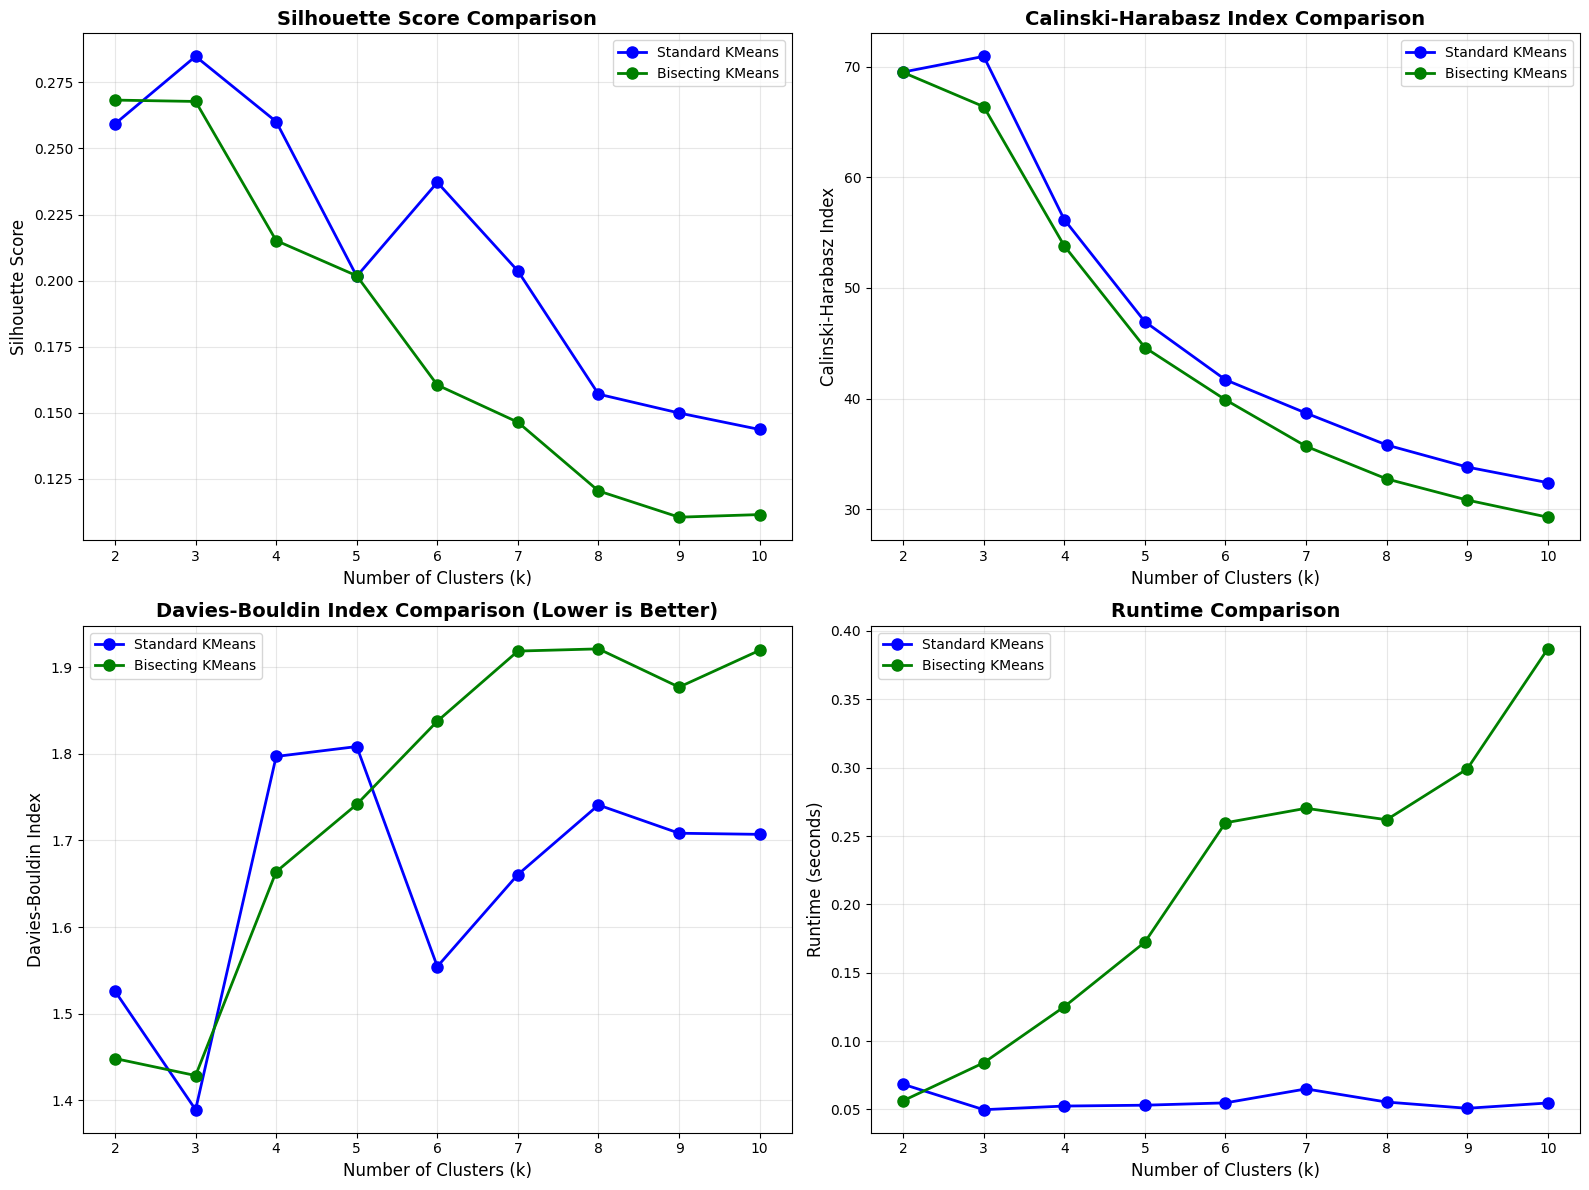

In [19]:
from sklearn.cluster import BisectingKMeans
import time
import numpy as np
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Compare Bisecting KMeans with Standard KMeans
bisecting_results = []

K = range(2, 11)

for k in K:
    # Standard KMeans
    start_time = time.time()
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    kmeans_runtime = time.time() - start_time
    kmeans_inertia = kmeans.inertia_
    kmeans_silhouette = silhouette_score(X, kmeans.labels_)
    kmeans_calinski = calinski_harabasz_score(X, kmeans.labels_)
    kmeans_davies = davies_bouldin_score(X, kmeans.labels_)
    
    # Bisecting KMeans
    start_time = time.time()
    bisecting = BisectingKMeans(n_clusters=k, random_state=42, n_init=10)
    bisecting.fit(X)
    bisecting_runtime = time.time() - start_time
    bisecting_inertia = bisecting.inertia_
    bisecting_silhouette = silhouette_score(X, bisecting.labels_)
    bisecting_calinski = calinski_harabasz_score(X, bisecting.labels_)
    bisecting_davies = davies_bouldin_score(X, bisecting.labels_)
    
    bisecting_results.append({
        'k': k,
        'KMeans_Silhouette': kmeans_silhouette,
        'Bisecting_Silhouette': bisecting_silhouette,
        'KMeans_Calinski': kmeans_calinski,
        'Bisecting_Calinski': bisecting_calinski,
        'KMeans_Davies': kmeans_davies,
        'Bisecting_Davies': bisecting_davies,
        'KMeans_Inertia': kmeans_inertia,
        'Bisecting_Inertia': bisecting_inertia,
        'KMeans_Runtime': kmeans_runtime,
        'Bisecting_Runtime': bisecting_runtime,
        'Speedup': kmeans_runtime / bisecting_runtime
    })

bisecting_df = pd.DataFrame(bisecting_results)
print(bisecting_df.to_string(index=False))

# Calculate average improvements
avg_silhouette_diff = (bisecting_df['Bisecting_Silhouette'] - bisecting_df['KMeans_Silhouette']).mean()
avg_calinski_diff = (bisecting_df['Bisecting_Calinski'] - bisecting_df['KMeans_Calinski']).mean()
avg_davies_diff = (bisecting_df['Bisecting_Davies'] - bisecting_df['KMeans_Davies']).mean()
avg_speedup = bisecting_df['Speedup'].mean()

print(f"Average Silhouette Difference: {avg_silhouette_diff:+.4f}")
print(f"Average Calinski-Harabasz Difference: {avg_calinski_diff:+.2f}")
print(f"Average Davies-Bouldin Difference: {avg_davies_diff:+.4f} (lower is better)")
print(f"Average Speedup: {avg_speedup:.2f}x")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Silhouette Score
axes[0, 0].plot(bisecting_df['k'], bisecting_df['KMeans_Silhouette'], 
                'bo-', label='Standard KMeans', linewidth=2, markersize=8)
axes[0, 0].plot(bisecting_df['k'], bisecting_df['Bisecting_Silhouette'], 
                'go-', label='Bisecting KMeans', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 0].set_title('Silhouette Score Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(K)

# Calinski-Harabasz Index
axes[0, 1].plot(bisecting_df['k'], bisecting_df['KMeans_Calinski'], 
                'bo-', label='Standard KMeans', linewidth=2, markersize=8)
axes[0, 1].plot(bisecting_df['k'], bisecting_df['Bisecting_Calinski'], 
                'go-', label='Bisecting KMeans', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Calinski-Harabasz Index', fontsize=12)
axes[0, 1].set_title('Calinski-Harabasz Index Comparison', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(K)

# Davies-Bouldin Index (lower is better)
axes[1, 0].plot(bisecting_df['k'], bisecting_df['KMeans_Davies'], 
                'bo-', label='Standard KMeans', linewidth=2, markersize=8)
axes[1, 0].plot(bisecting_df['k'], bisecting_df['Bisecting_Davies'], 
                'go-', label='Bisecting KMeans', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 0].set_title('Davies-Bouldin Index Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(K)

# Runtime Comparison
axes[1, 1].plot(bisecting_df['k'], bisecting_df['KMeans_Runtime'], 
                'bo-', label='Standard KMeans', linewidth=2, markersize=8)
axes[1, 1].plot(bisecting_df['k'], bisecting_df['Bisecting_Runtime'], 
                'go-', label='Bisecting KMeans', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Runtime (seconds)', fontsize=12)
axes[1, 1].set_title('Runtime Comparison', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(K)

plt.tight_layout()
plt.show()

## Fuzzy C-Means Implementation

• Average FPC: 0.2922
• Best FPC at k=2: 0.6004

Average Membership Certainty:
• How confident the algorithm is in assignments
• Average certainty: 0.3755


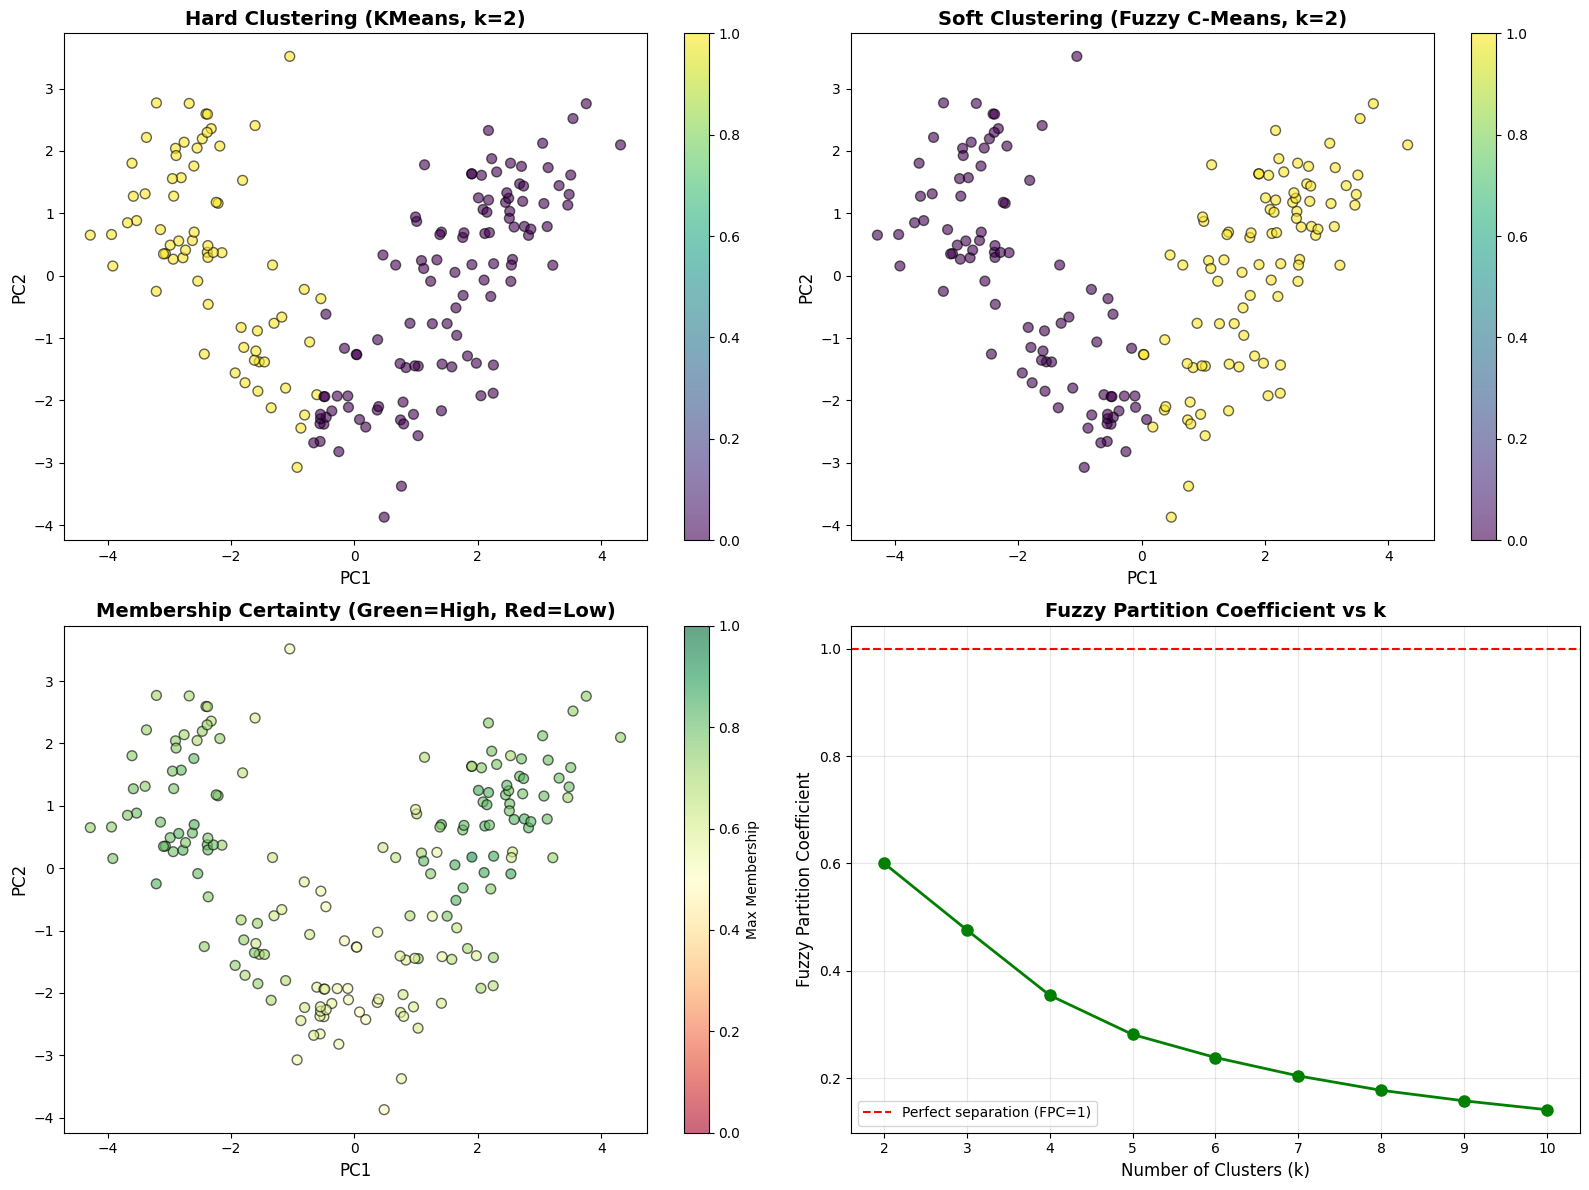

SAMPLE MEMBERSHIP MATRIX (first 5 points):
         Cluster 0  Cluster 1
Point 0   0.215968   0.784032
Point 1   0.248677   0.751323
Point 2   0.204947   0.795053
Point 3   0.264510   0.735490
Point 4   0.327004   0.672996


In [21]:
import skfuzzy as fuzz

# Implement Fuzzy C-Means
fuzzy_results = []

for k in K:
    # Standard KMeans (hard clustering)
    start_time = time.time()
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X)
    kmeans_runtime = time.time() - start_time
    kmeans_silhouette = silhouette_score(X, kmeans_labels)
    
    # Fuzzy C-Means (soft clustering)
    start_time = time.time()
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        X.T, k, 2, error=0.005, maxiter=1000, init=None, seed=42
    )
    fuzzy_runtime = time.time() - start_time
    
    # Convert fuzzy membership to hard labels
    fuzzy_labels = np.argmax(u, axis=0)
    fuzzy_silhouette = silhouette_score(X, fuzzy_labels)
    
    # Calculate fuzzy partition coefficient (FPC)
    # FPC ranges from 0 to 1, with 1 being best (crisp clustering)
    fpc_score = fpc
    
    # Calculate average membership certainty
    max_memberships = np.max(u, axis=0)
    avg_certainty = np.mean(max_memberships)
    
    fuzzy_results.append({
        'k': k,
        'KMeans_Silhouette': kmeans_silhouette,
        'Fuzzy_Silhouette': fuzzy_silhouette,
        'KMeans_Runtime': kmeans_runtime,
        'Fuzzy_Runtime': fuzzy_runtime,
        'FPC': fpc_score,
        'Avg_Certainty': avg_certainty,
        'Speedup': fuzzy_runtime / kmeans_runtime
    })

fuzzy_df = pd.DataFrame(fuzzy_results)

print(f"• Average FPC: {fuzzy_df['FPC'].mean():.4f}")
print(f"• Best FPC at k={fuzzy_df.loc[fuzzy_df['FPC'].idxmax(), 'k']}: {fuzzy_df['FPC'].max():.4f}")

print("\nAverage Membership Certainty:")
print("• How confident the algorithm is in assignments")
print(f"• Average certainty: {fuzzy_df['Avg_Certainty'].mean():.4f}")

# Visualize membership for optimal k
optimal_k_fuzzy = int(fuzzy_df.loc[fuzzy_df['FPC'].idxmax(), 'k'])
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X.T, optimal_k_fuzzy, 2, error=0.005, maxiter=1000, init=None, seed=42
)

# PCA for visualization
from sklearn.decomposition import PCA
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Hard clustering (KMeans)
kmeans_viz = KMeans(n_clusters=optimal_k_fuzzy, random_state=42)
kmeans_labels_viz = kmeans_viz.fit_predict(X)

scatter1 = axes[0, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                             c=kmeans_labels_viz, cmap='viridis',
                             s=50, alpha=0.6, edgecolors='k')
axes[0, 0].set_title(f'Hard Clustering (KMeans, k={optimal_k_fuzzy})', 
                    fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('PC1', fontsize=12)
axes[0, 0].set_ylabel('PC2', fontsize=12)
plt.colorbar(scatter1, ax=axes[0, 0])

# Soft clustering (Fuzzy C-Means) - colored by most likely cluster
fuzzy_labels_viz = np.argmax(u, axis=0)
scatter2 = axes[0, 1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                             c=fuzzy_labels_viz, cmap='viridis',
                             s=50, alpha=0.6, edgecolors='k')
axes[0, 1].set_title(f'Soft Clustering (Fuzzy C-Means, k={optimal_k_fuzzy})', 
                    fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('PC1', fontsize=12)
axes[0, 1].set_ylabel('PC2', fontsize=12)
plt.colorbar(scatter2, ax=axes[0, 1])

# Membership certainty visualization
max_memberships_viz = np.max(u, axis=0)
scatter3 = axes[1, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                             c=max_memberships_viz, cmap='RdYlGn',
                             s=50, alpha=0.6, edgecolors='k', vmin=0, vmax=1)
axes[1, 0].set_title('Membership Certainty (Green=High, Red=Low)', 
                    fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('PC1', fontsize=12)
axes[1, 0].set_ylabel('PC2', fontsize=12)
cbar = plt.colorbar(scatter3, ax=axes[1, 0])
cbar.set_label('Max Membership', fontsize=10)

# FPC across k values
axes[1, 1].plot(fuzzy_df['k'], fuzzy_df['FPC'], 'go-', linewidth=2, markersize=8)
axes[1, 1].axhline(y=1.0, color='r', linestyle='--', label='Perfect separation (FPC=1)')
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Fuzzy Partition Coefficient', fontsize=12)
axes[1, 1].set_title('Fuzzy Partition Coefficient vs k', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(K)

plt.tight_layout()
plt.show()

# Show membership matrix for a few sample points
print("SAMPLE MEMBERSHIP MATRIX (first 5 points):")
membership_df = pd.DataFrame(u[:, :5].T, 
                             columns=[f'Cluster {i}' for i in range(optimal_k_fuzzy)],
                             index=[f'Point {i}' for i in range(5)])
print(membership_df.to_string())

avg_silhouette_diff_fuzzy = (fuzzy_df['Fuzzy_Silhouette'] - fuzzy_df['KMeans_Silhouette']).mean()